<a href="https://colab.research.google.com/github/mehhdiii/surface-classification-using-imu-data/blob/main/ML_floor_surface_detection_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
function keepColabAlive() {
  setInterval(() => {
    console.log("Keeping Colab alive...");
    document.querySelector("colab-toolbar-button").click();
  }, 30000);
}
keepColabAlive();


SyntaxError: invalid syntax (<ipython-input-29-4f7ea252fff1>, line 1)

In [ ]:
!pip install scikit-learn
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install joblib
!pip install google
!pip install google-colab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.7 MB/s eta 0:00:00


In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import seaborn as sns

In [4]:
from google.colab import drive
drive.mount('/content/drive')
x_path = "/content/drive/MyDrive/ML-data/X_train.csv"
y_path = "/content/drive/MyDrive/ML-data/y_train.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# # if running locally
# x_path = "./data/X_train.csv"
# y_path = "./data/y_train.csv"

# Load data

In [5]:
# X, y = make_classification(n_samples=1000, n_features=10, n_classes=5, n_informative=4, random_state=42)
X = pd.read_csv(x_path)  # Replace with your actual CSV file
y = pd.read_csv(y_path)  # Replace with your actual CSV file
df = X.merge(y, on='series_id', how='inner')
X = df.drop(columns=['row_id', 'series_id', 'measurement_number', 'surface', 'group_id'])
y = df['surface']

In [6]:
print(X.shape)
print(y.shape)

(487680, 10)
(487680,)


# Data Exploration

In [22]:
X.head()

,orientation_X,orientation_Y,orientation_Z,orientation_W,angular_velocity_X,angular_velocity_Y,angular_velocity_Z,linear_acceleration_X,linear_acceleration_Y,linear_acceleration_Z
0,-0.75853,-0.63435,-0.10488,-0.10597,0.107650,0.017561,0.000767,-0.74857,2.1030,-9.7532
1,-0.75853,-0.63434,-0.10490,-0.10600,0.067851,0.029939,0.003386,0.33995,1.5064,-9.4128
2,-0.75853,-0.63435,-0.10492,-0.10597,0.007275,0.028934,-0.005978,-0.26429,1.5922,-8.7267
3,-0.75852,-0.63436,-0.10495,-0.10597,-0.013053,0.019448,-0.008974,0.42684,1.0993,-10.0960
4,-0.75852,-0.63435,-0.10495,-0.10596,0.005135,0.007652,0.005245,-0.50969,1.4689,-10.4410


In [8]:
print(y.head())

0    fine_concrete
1    fine_concrete
2    fine_concrete
3    fine_concrete
4    fine_concrete
Name: surface, dtype: object


In [9]:
y.unique()

array(['fine_concrete', 'concrete', 'soft_tiles', 'tiled', 'soft_pvc',
       'hard_tiles_large_space', 'carpet', 'hard_tiles', 'wood'],
      dtype=object)

In [10]:
zero_counts = (X == 0).sum()
print("Zero counts per feature: ")
print(zero_counts)

zero_proportions = (X == 0).mean()
print("\nZero proportions per feature: ")
print(zero_proportions)

# Total percentage of zeros in the entire dataset
total_zeros = (X == 0).sum().sum()
total_elements = X.size
total_zeros_percentage = (total_zeros / total_elements) * 100

Zero counts per feature: 
orientation_X            0
orientation_Y            0
orientation_Z            0
orientation_W            0
angular_velocity_X       2
angular_velocity_Y       2
angular_velocity_Z       1
linear_acceleration_X    0
linear_acceleration_Y    0
linear_acceleration_Z    0
dtype: int64

Zero proportions per feature: 
orientation_X            0.000000
orientation_Y            0.000000
orientation_Z            0.000000
orientation_W            0.000000
angular_velocity_X       0.000004
angular_velocity_Y       0.000004
angular_velocity_Z       0.000002
linear_acceleration_X    0.000000
linear_acceleration_Y    0.000000
linear_acceleration_Z    0.000000
dtype: float64




---



> From the above analysis, we conclude that the given data is not sparse.



# Prepocessing

## scale data

In [11]:
from sklearn import preprocessing

scaler = preprocessing.StandardScaler().fit(X)
X_Scaled = scaler.transform(X)
print("Original mean:")
print(X.mean(axis=0))

print("Scaled mean:")
print(X_Scaled.mean(axis=0))

Original mean:
orientation_X           -0.018050
orientation_Y            0.075062
orientation_Z            0.012458
orientation_W           -0.003804
angular_velocity_X       0.000178
angular_velocity_Y       0.008338
angular_velocity_Z      -0.019184
linear_acceleration_X    0.129281
linear_acceleration_Y    2.886468
linear_acceleration_Z   -9.364886
dtype: float64
Scaled mean:
[-1.67844741e-17 -1.77169449e-17  1.81831802e-17  3.21702420e-17
  1.07816934e-17 -2.62257407e-17 -3.11212123e-17  8.69820401e-18
  1.81715244e-16 -8.99171376e-16]


## label encode Y

In [12]:
le = preprocessing.LabelEncoder()
y_encoded = le.fit_transform(y)
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Enoding:")
print(label_mapping)

Enoding:
{'carpet': 0, 'concrete': 1, 'fine_concrete': 2, 'hard_tiles': 3, 'hard_tiles_large_space': 4, 'soft_pvc': 5, 'soft_tiles': 6, 'tiled': 7, 'wood': 8}


## split data

In [23]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_Scaled, y_encoded, test_size=0.2, random_state=42)

# Data visualization

Surfaces frequency distribution in train dataset:
surface
concrete                  99712
soft_pvc                  93696
wood                      77696
tiled                     65792
fine_concrete             46464
hard_tiles_large_space    39424
soft_tiles                38016
carpet                    24192
hard_tiles                 2688
Name: count, dtype: int64


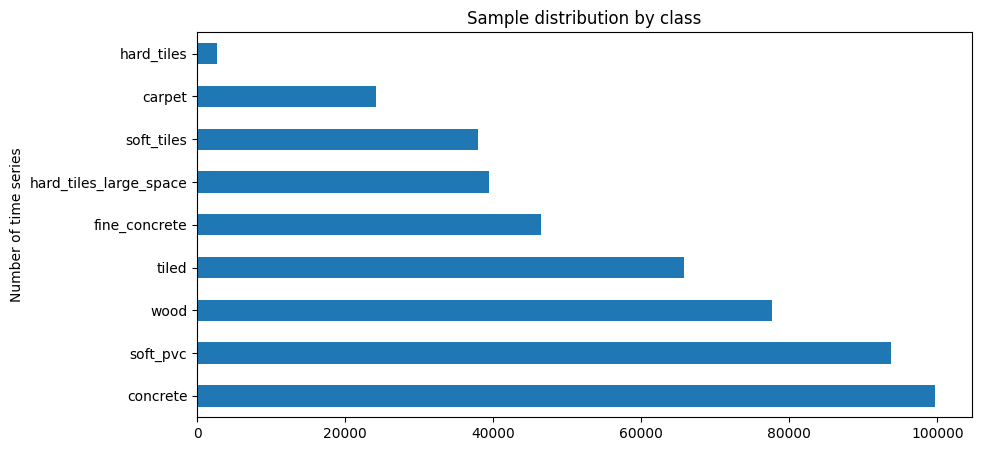

In [26]:
train_freq_distribution_surfaces = df.surface.value_counts()

print(f"Surfaces frequency distribution in train dataset:\n{train_freq_distribution_surfaces}")
train_freq_distribution_surfaces.plot(kind="barh", figsize=(10,5))
plt.title("Sample distribution by class")
plt.ylabel("Number of time series")
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packa

ValueError: could not convert string to float: 'fine_concrete'

<Figure size 640x480 with 0 Axes>

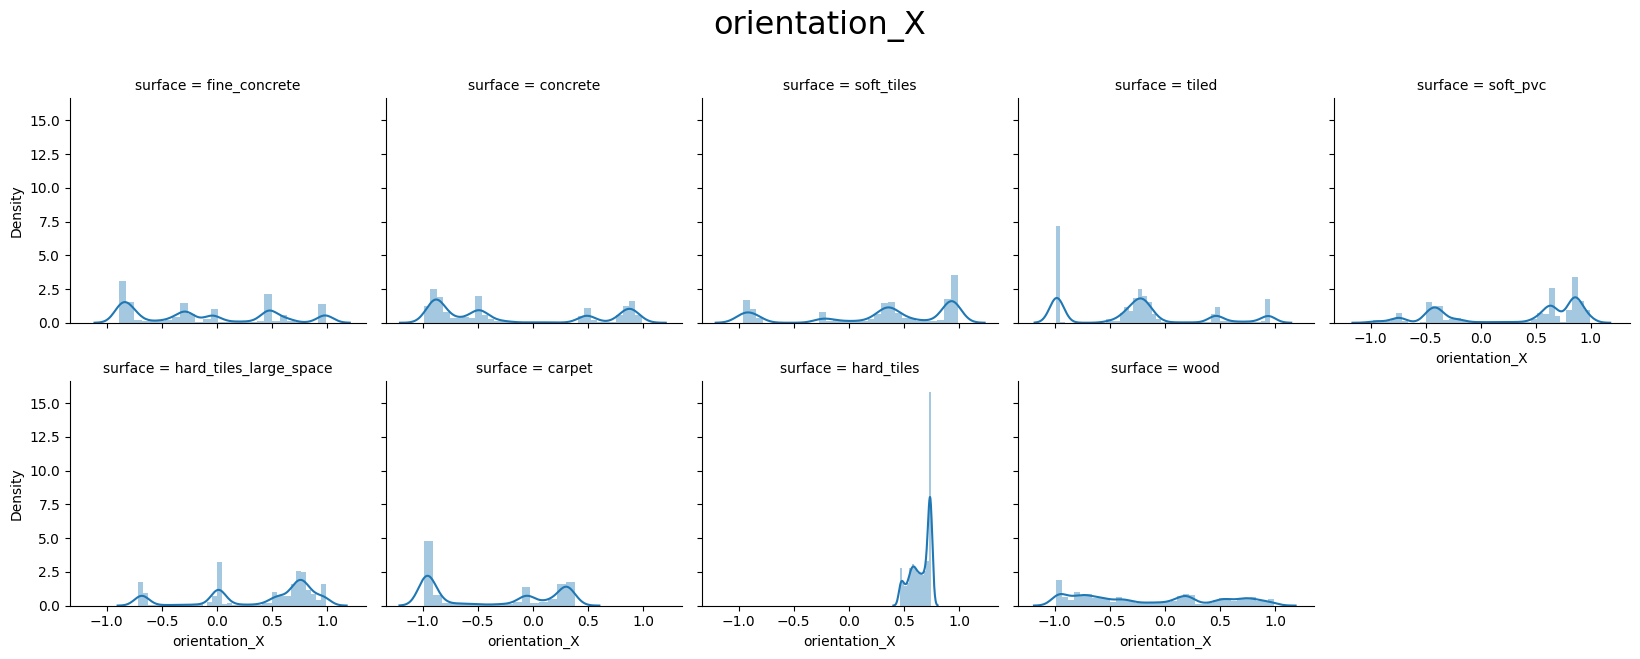

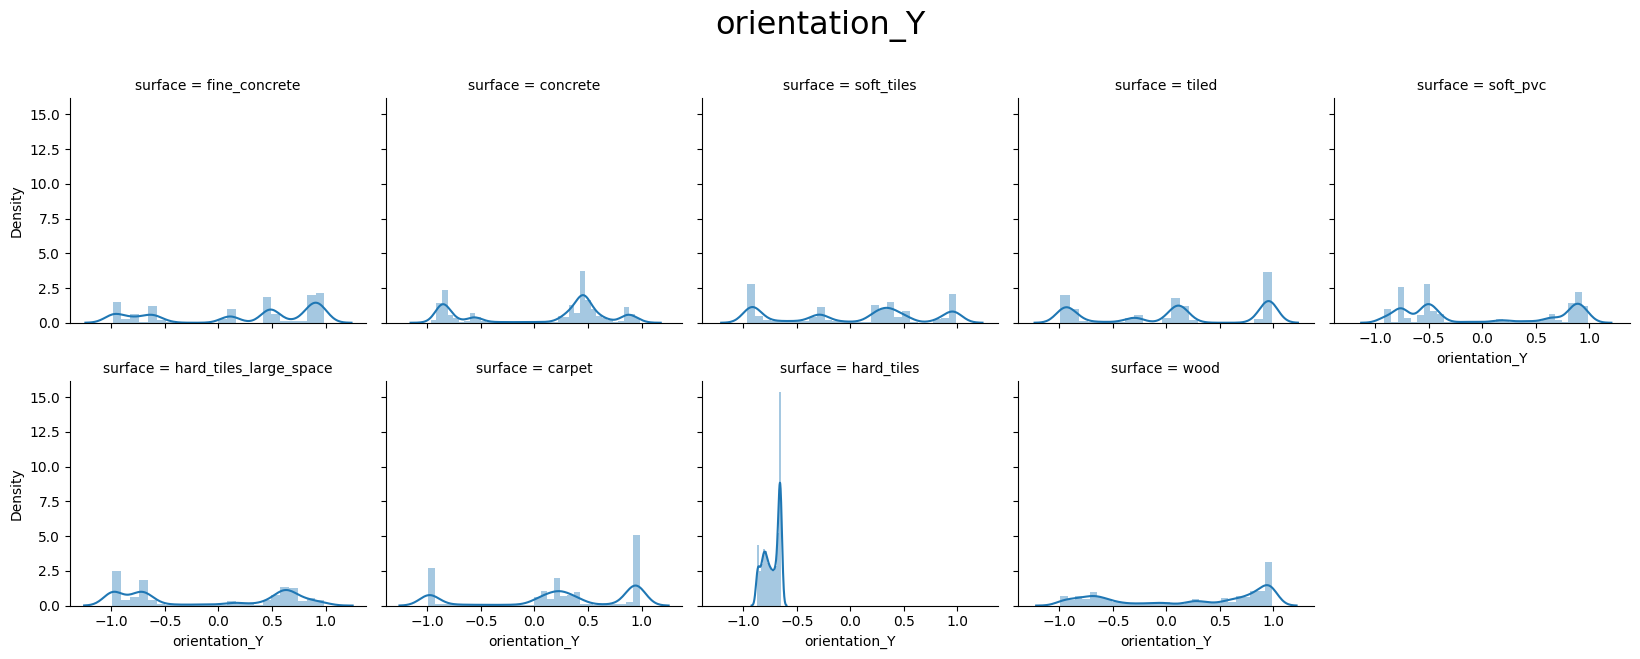

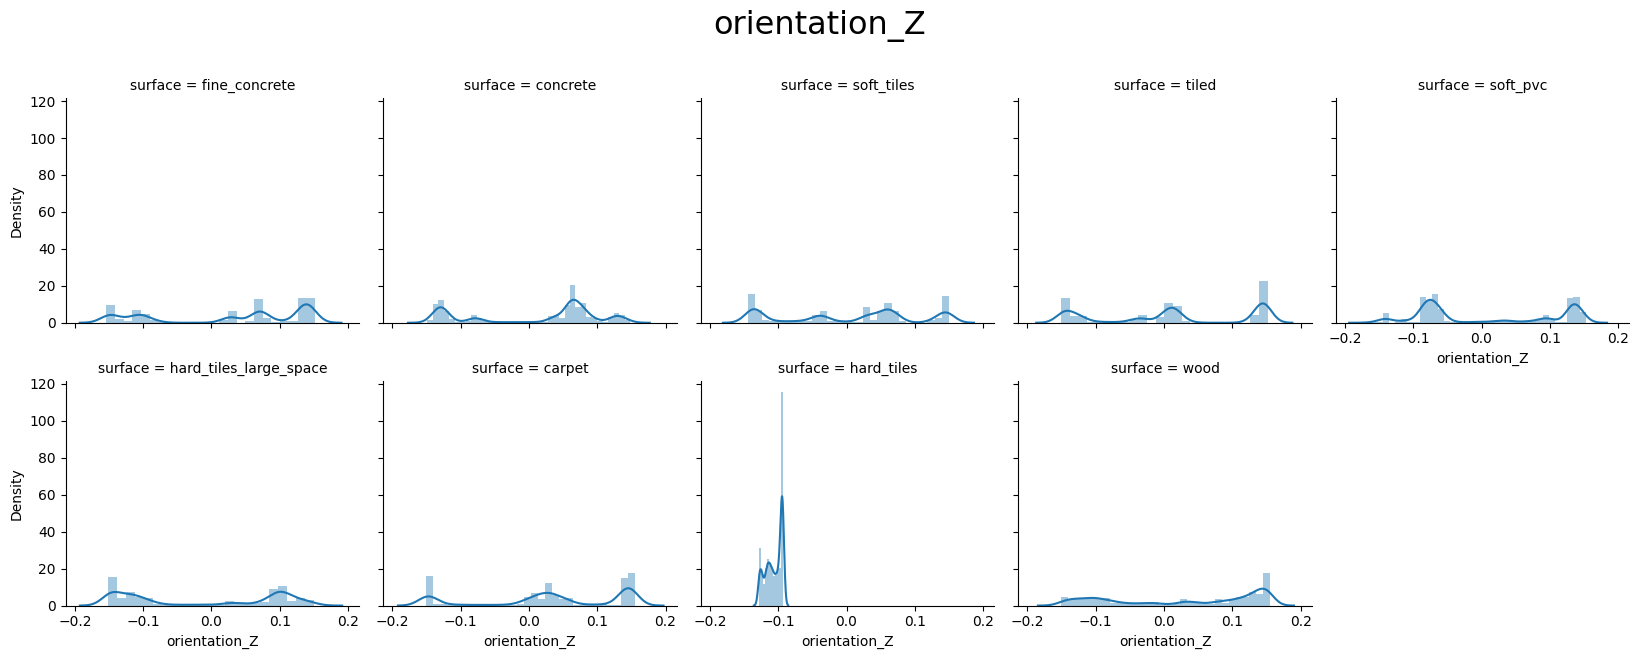

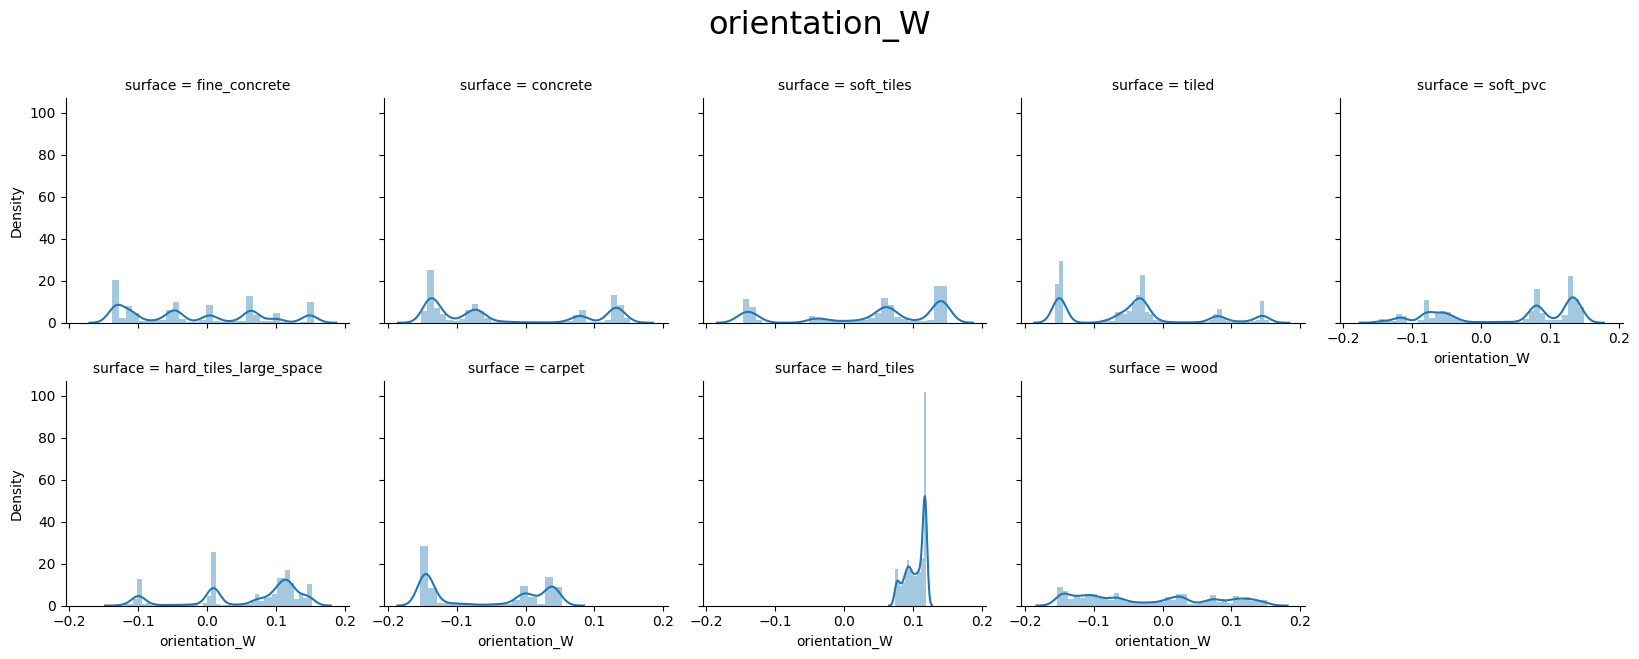

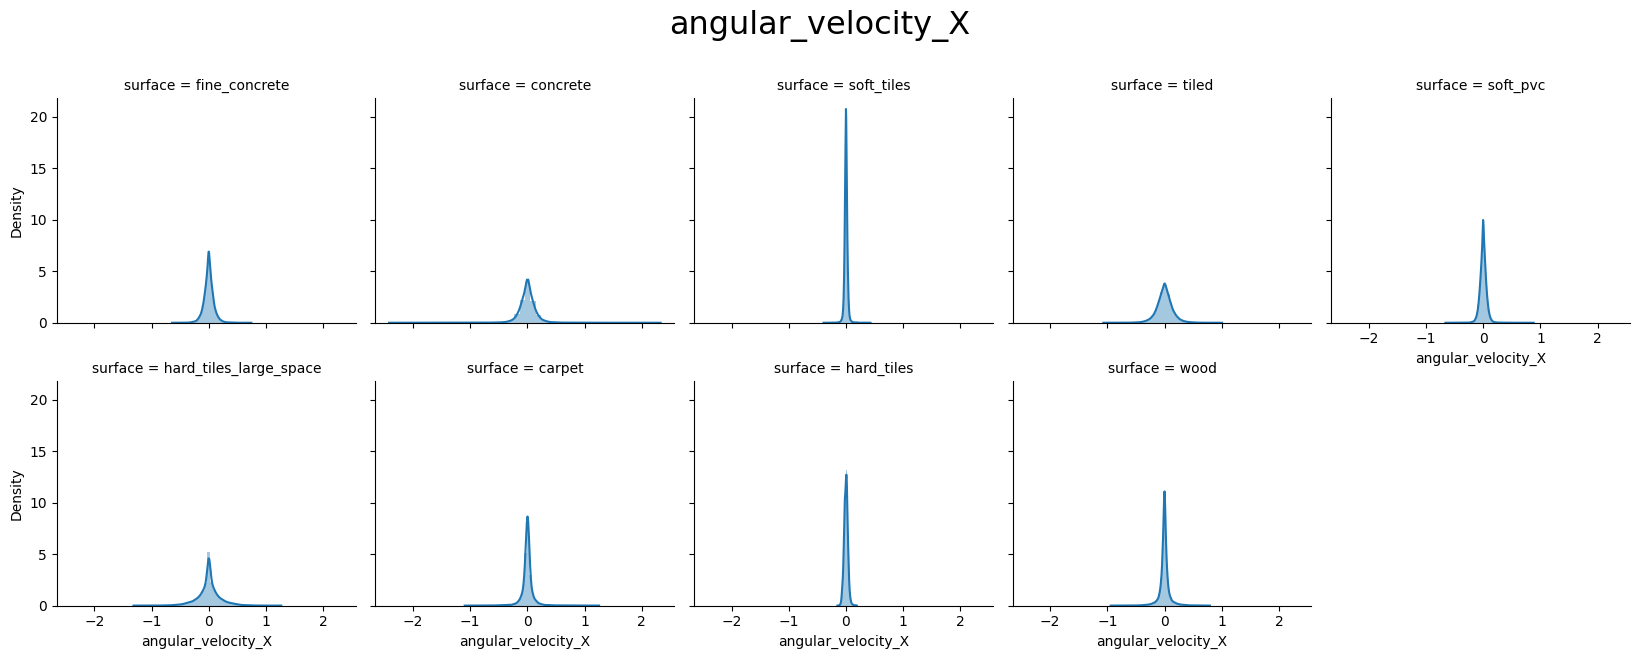

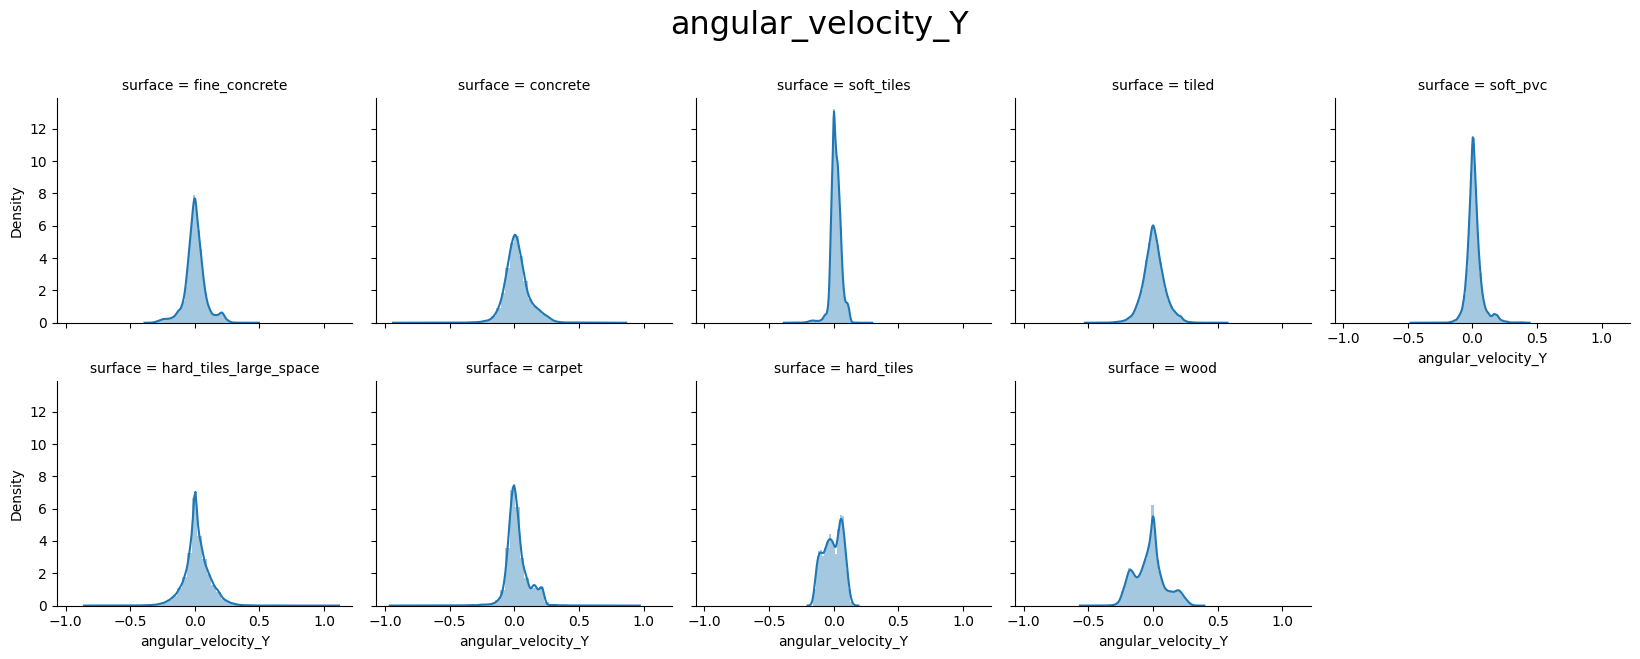

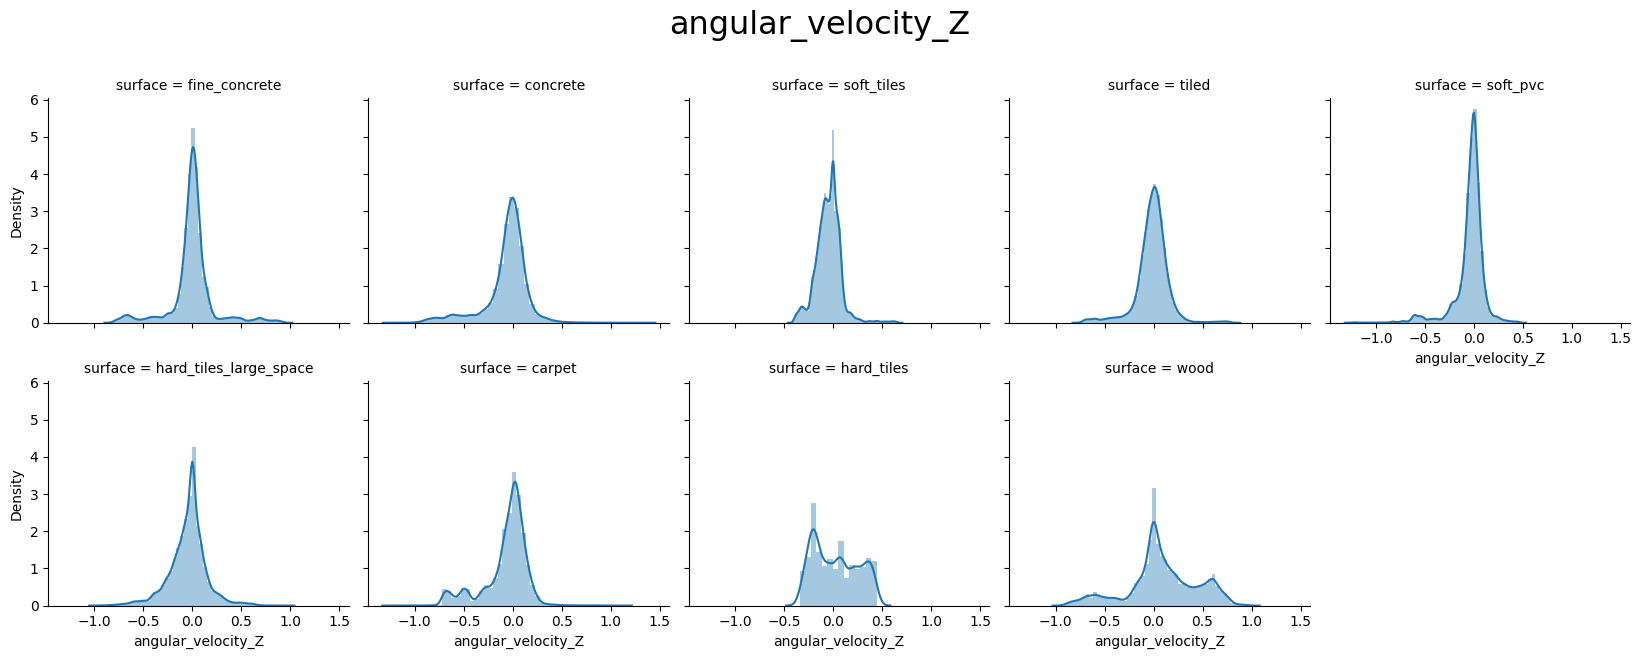

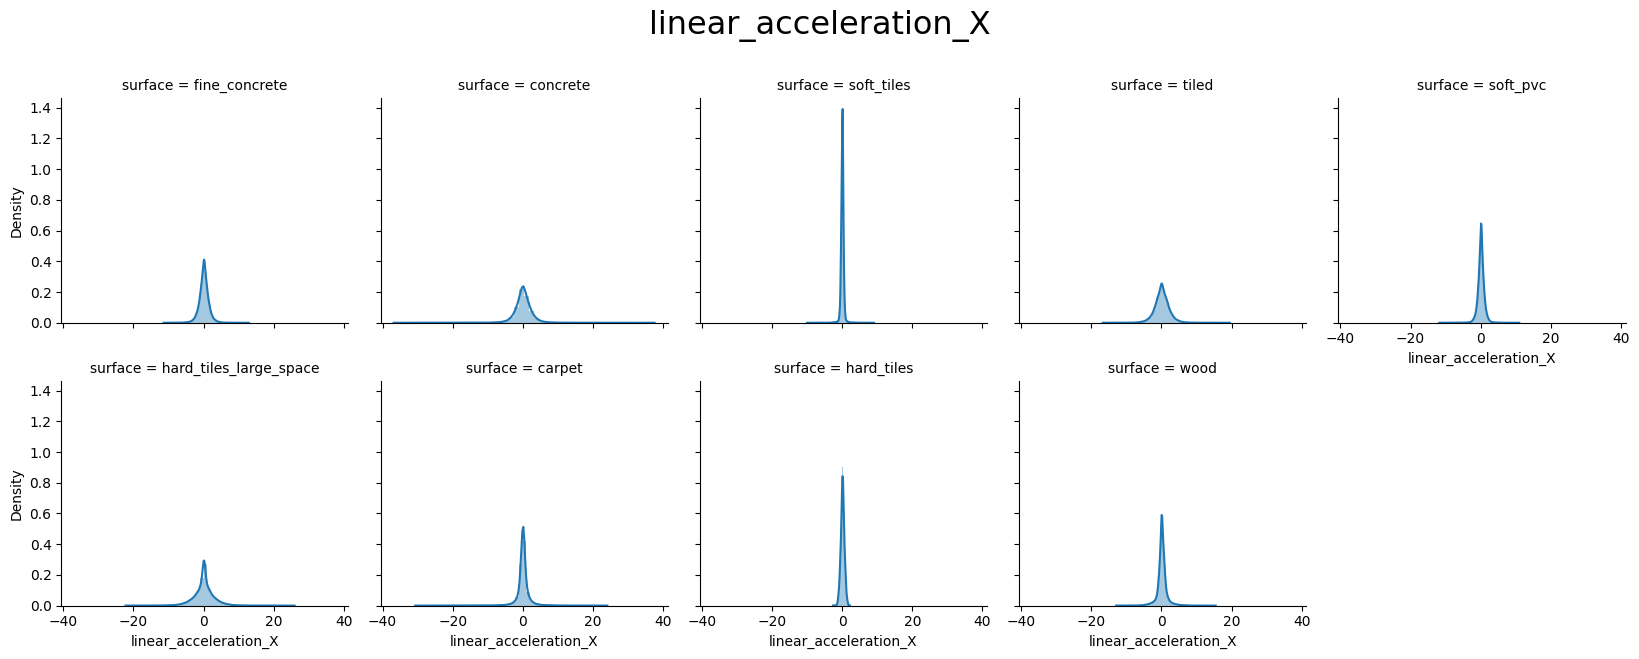

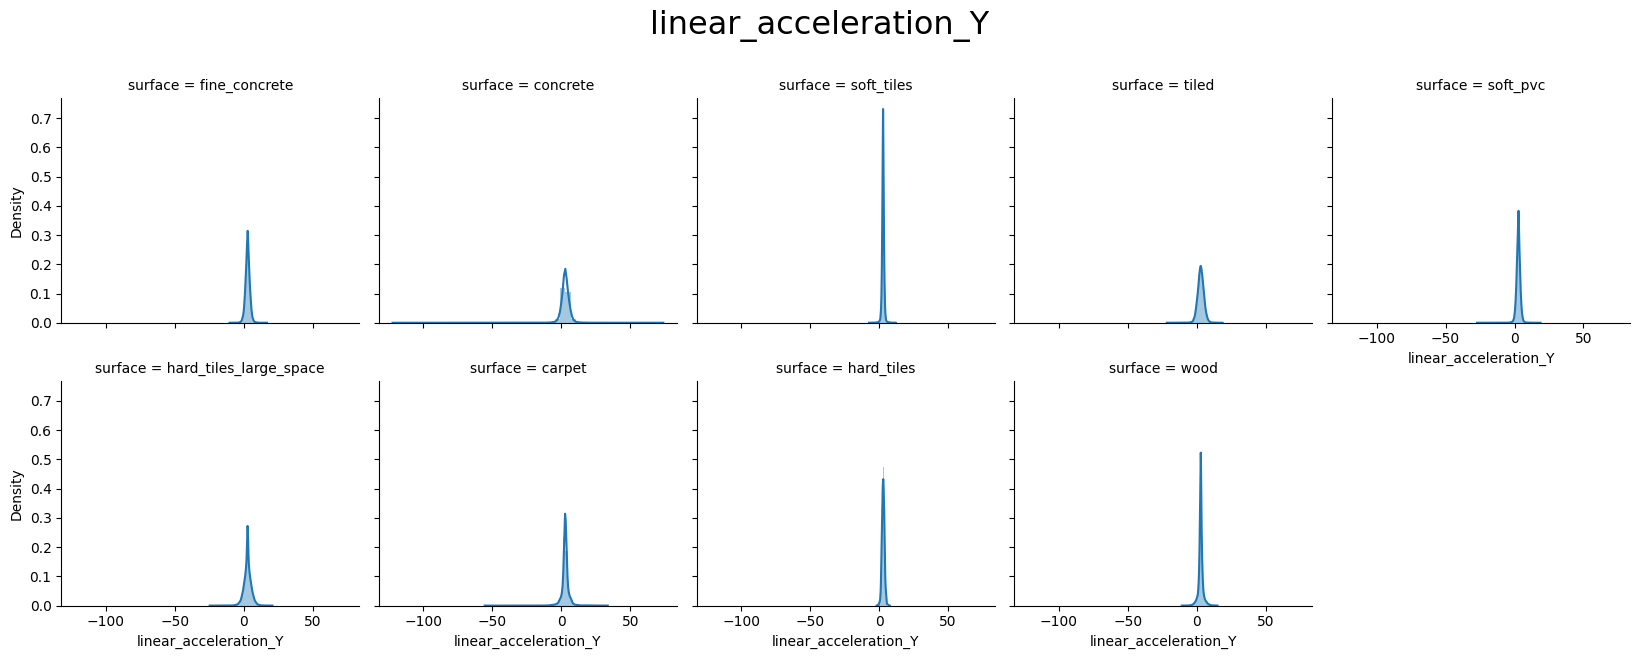

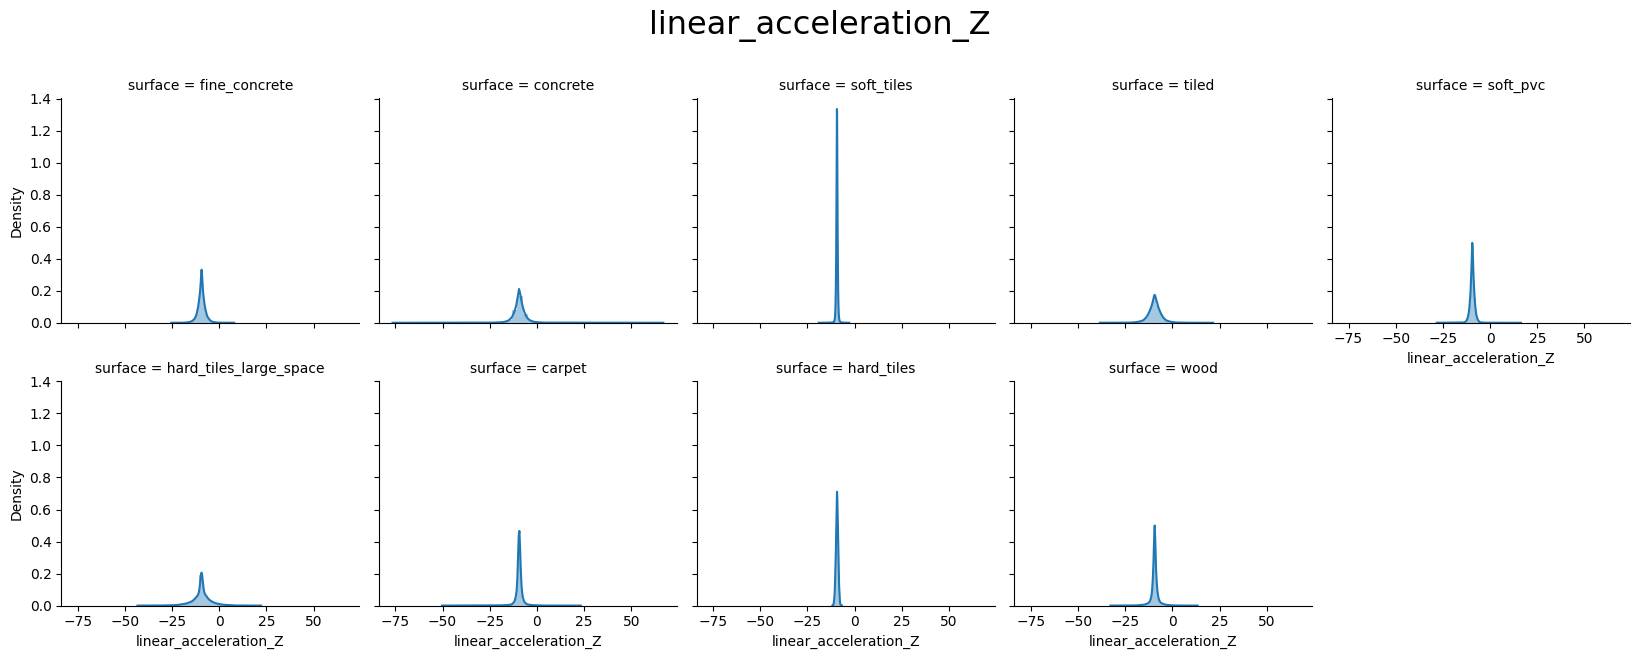

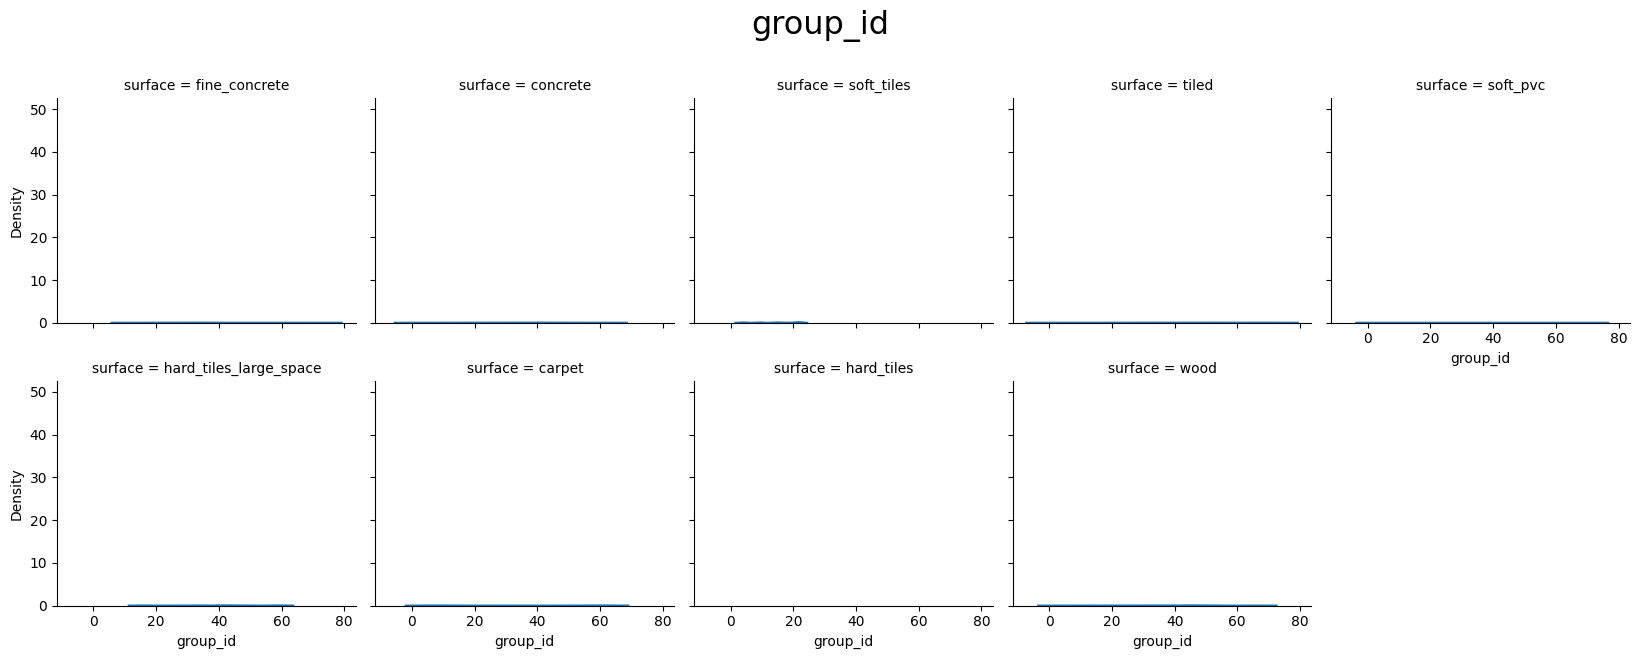

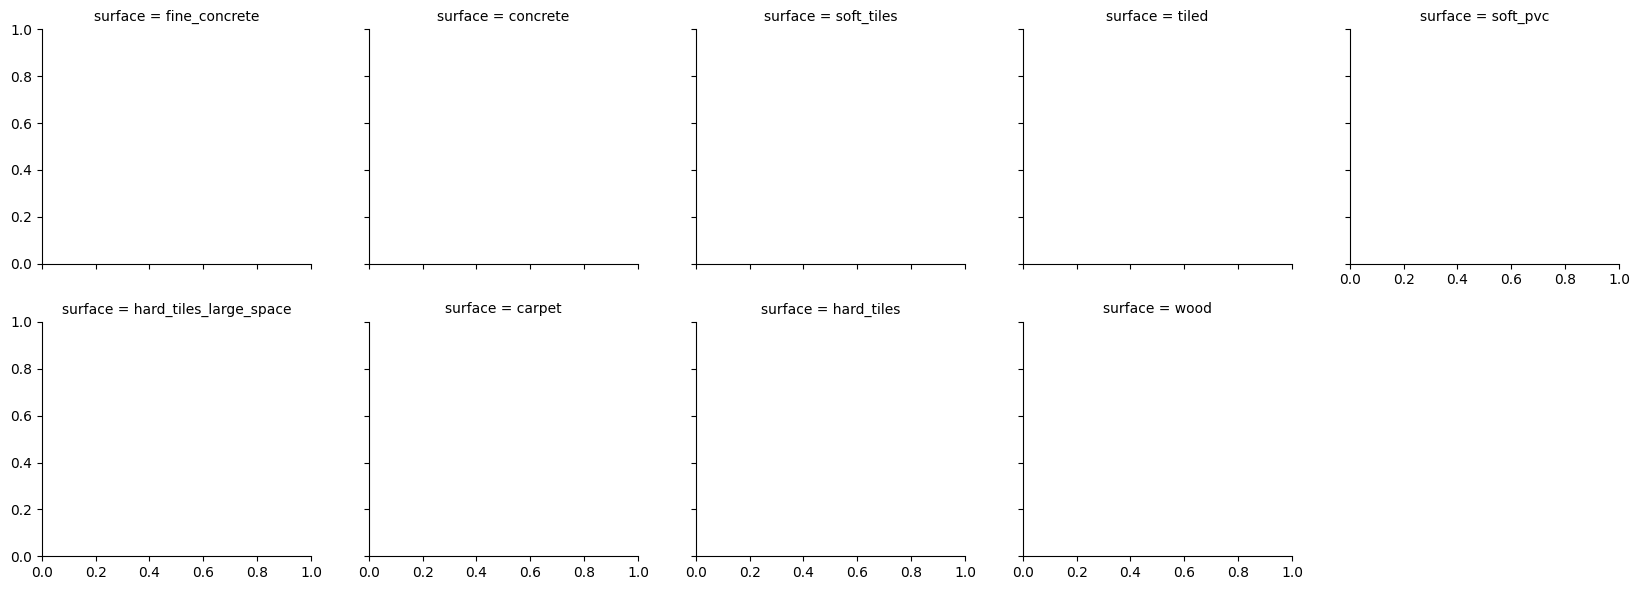

In [29]:
plt.subplots_adjust(top=0.8)
for i, col in enumerate(df.columns[3:]):
    g = sns.FacetGrid(df, col="surface", col_wrap=5, height=3, aspect=1.1)
    g = g.map(sns.distplot, col)
    g.fig.suptitle(col, y=1.09, fontsize=23)


In [ ]:
# pca with knn:
from sklearn.decomposition import PCA
# Step 3: Apply PCA
pca = PCA(n_components=2)  # You can change the number of components
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.fit_transform(X_test)

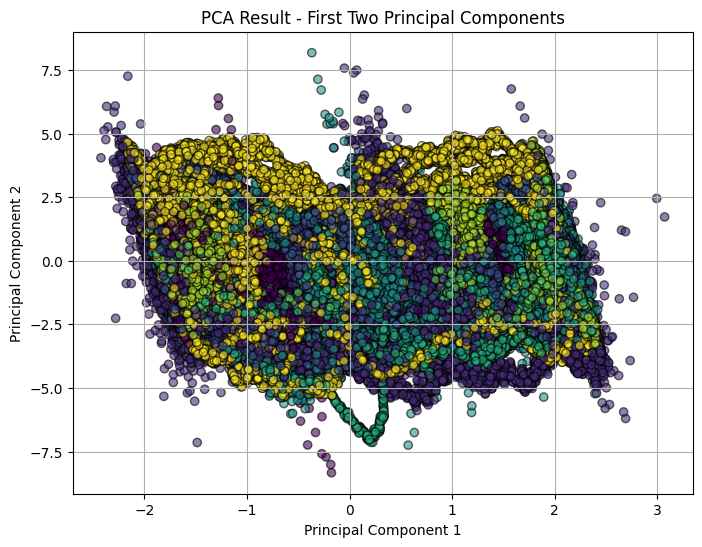

In [ ]:
pca_df = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])

# Step 5: Plot the PCA result
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=y_train, edgecolor='k', alpha=0.6)
plt.title('PCA Result - First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

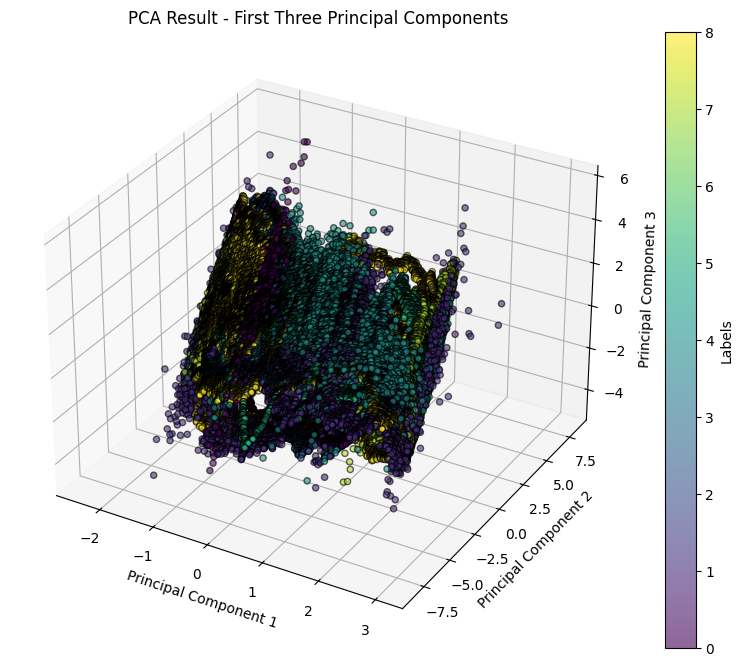

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Step 3: Apply PCA and reduce to 3 components
pca = PCA(n_components=3)  # Reduce to 3 components for 3D plot
pca_components = pca.fit_transform(X_train)

# Step 4: Create a new DataFrame with the PCA results
pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2', 'PC3'])

# Step 5: Plot the PCA result in 3D, color points based on the labels in y
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], c=y_train, cmap='viridis', edgecolor='k', alpha=0.6)

# Add color bar
plt.colorbar(scatter, label='Labels')

# Title and labels
ax.set_title('PCA Result - First Three Principal Components')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

plt.show()


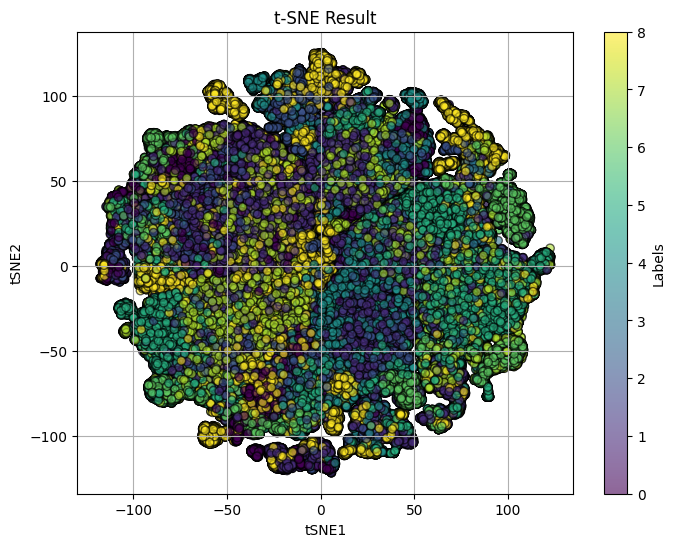

In [ ]:
from sklearn.manifold import TSNE

# Step 1: Apply t-SNE for 2D visualization
tsne = TSNE(n_components=2, random_state=42)
tsne_components = tsne.fit_transform(X_train)

# Step 2: Create a new DataFrame with the t-SNE results
tsne_df = pd.DataFrame(tsne_components, columns=['tSNE1', 'tSNE2'])

# Step 3: Plot the t-SNE result, color points based on the labels in y
plt.figure(figsize=(8, 6))
scatter = plt.scatter(tsne_df['tSNE1'], tsne_df['tSNE2'], c=y_train, cmap='viridis', edgecolor='k', alpha=0.6)

# Add color bar
plt.colorbar(scatter, label='Labels')

# Title and labels
plt.title('t-SNE Result')
plt.xlabel('tSNE1')
plt.ylabel('tSNE2')
plt.grid(True)

plt.show()

# Random forest

In [ ]:
max_features_list = [4] # close to square root of maximum available features.
tree_count_list = [100]

In [ ]:
outputs = {
}
max_accuracy = {'value': -float('inf'), 'tree_count': None, 'max_features': None, 'tree_index': None, 'max_feature_index': None }

In [ ]:
for tree_index, tree_count in enumerate(tree_count_list):
  accuracy_list = []
  precision_list = []
  recall_list = []
  f1_list = []

  for max_feature_index, max_features in enumerate(max_features_list):
    print("training with n_estimators: ", tree_count, ", max_features:", max_features)
    clf = RandomForestClassifier(n_estimators=tree_count, oob_score=True, max_features= max_features, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # evaulate scores
    accuracy = accuracy_score(y_test, y_pred)
    print('accuracy: ', accuracy)

    if accuracy > max_accuracy['value']:

      max_accuracy['value'] = accuracy # store max accuracy
      max_accuracy['tree_count'] = tree_count
      max_accuracy['max_features'] = max_features
      max_accuracy['tree_index'] = tree_index
      max_accuracy['max_feature_index'] = max_feature_index
      max_accuracy['clf'] = clf


    precision = precision_score(y_test, y_pred, average='macro') # false positive indicator
    recall = recall_score(y_test, y_pred, average='macro') # false negative indicator
    f1 = f1_score(y_test, y_pred, average='macro') # aggregate score of precision and recall
    print(f"Accuracy: {accuracy}")
    accuracy_list.append(accuracy)
    print(f"Precision: {precision}")
    precision_list.append(precision)
    print(f"Recall: {recall}")
    recall_list.append(recall)
    print(f"F1: {f1}")
    f1_list.append(f1)

    # forcefully break the loop if accuracy goes beyond 95%:

  outputs[tree_count] = {
    'accuracy_list': accuracy_list,
    'precision_list': precision_list,
    'recall_list': recall_list,
    'f1_list': f1_list
  }
  if max_accuracy['value']>0.95:
    stop_training = True
    break

training with n_estimators:  8 , max_features: 4


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


accuracy:  0.9821296751968503
Accuracy: 0.9821296751968503
Precision: 0.9817893373473215
Recall: 0.9828023062305902
F1: 0.9822622361457474


In [ ]:
import joblib
joblib.dump(max_accuracy['clf'], "/content/drive/MyDrive/ML-trained-models/RF_model.pkl")
print("Model saved successfully!")

Model saved successfully!


## Feature importance

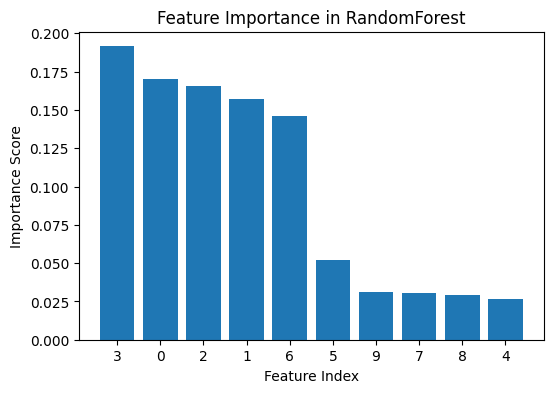

In [ ]:

importances = max_accuracy['clf'].feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(6, 4))
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), indices)
plt.xlabel("Feature Index")
plt.ylabel("Importance Score")
plt.title("Feature Importance in RandomForest")
plt.show()

## Confusion Matrix

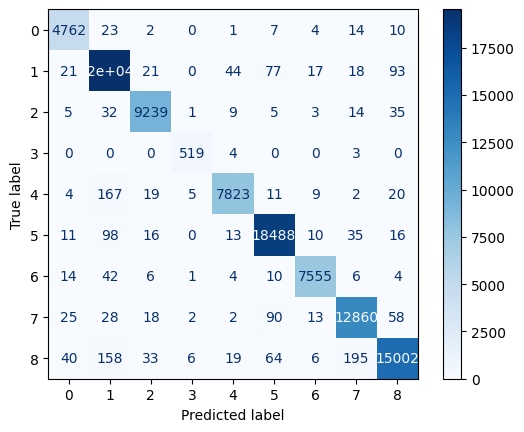

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split


# Predict and plot confusion matrix
y_pred = max_accuracy['clf'].predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()


## Metrics

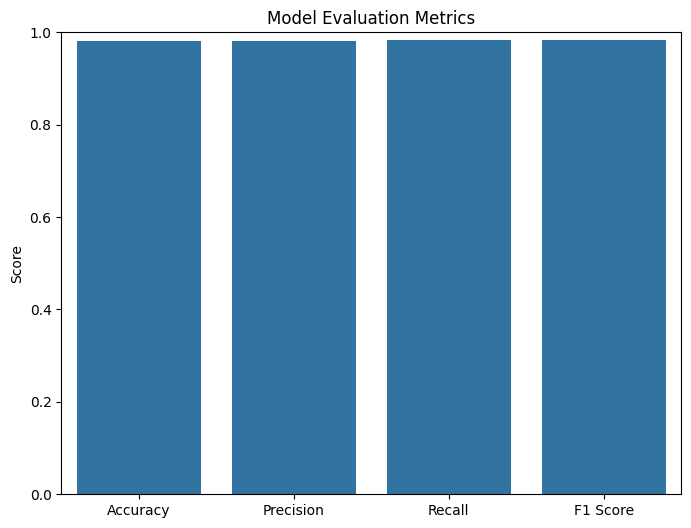

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

y_pred = clf.predict(X_test)
# evaulate scores
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro') # false positive indicator
recall = recall_score(y_test, y_pred, average='macro') # false negative indicator
f1 = f1_score(y_test, y_pred, average='macro') # aggregate score of precision and recall
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 6))
sns.barplot(x=metrics, y=values)
plt.title('Model Evaluation Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.show()

# LGBMClassifier

In [ ]:
import lightgbm as lgb

# Create the model
lgbm = lgb.LGBMClassifier(objective='multiclass', is_unbalance=True, max_depth=10,
                               learning_rate=0.05, n_estimators=500, num_leaves=30)

lgbm.fit(X_train, y_train,
            # eval_set=[(X_train, Y_train), (X_validation, Y_validation)],
            # early_stopping_rounds=60, # stops if 60 consequent rounds without decrease of error
            # verbose=False,
         eval_metric='multi_error'
            )

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034780 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 390144, number of used features: 10
[LightGBM] [Info] Start training from score -3.002842
[LightGBM] [Info] Start training from score -1.586040
[LightGBM] [Info] Start training from score -2.352333
[LightGBM] [Info] Start training from score -5.195482
[LightGBM] [Info] Start training from score -2.520855
[LightGBM] [Info] Start training from score -1.648908
[LightGBM] [Info] Start training from score -2.552929
[LightGBM] [Info] Start training from score -2.001976
[LightGBM] [Info] Start training from score -1.836595


LGBMClassifier(is_unbalance=True, learning_rate=0.05, max_depth=10,
               n_estimators=500, num_leaves=30, objective='multiclass')

In [ ]:
y_pred = lgbm.predict(X_test)  # Assuming X_test is your test data

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Accuracy: 96.8894
Precision: 97.0593
Recall: 97.1127
F1 Score: 97.0839


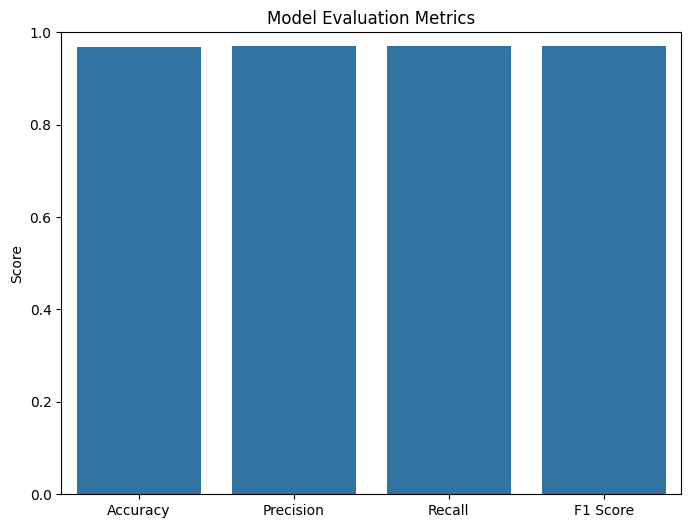

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')  # Use 'macro' for multiclass
recall = recall_score(y_test, y_pred, average='macro')  # Use 'macro' for multiclass
f1 = f1_score(y_test, y_pred, average='macro')  # Use 'macro' for multiclass

print(f"Accuracy: {accuracy*100:.4f}")
print(f"Precision: {precision*100:.4f}")
print(f"Recall: {recall*100:.4f}")
print(f"F1 Score: {f1*100:.4f}")

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]
plt.figure(figsize=(8, 6))
sns.barplot(x=metrics, y=values)
plt.title('Model Evaluation Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.show()

# K-Nearest Neighbors (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
class KNNModel:
    def __init__(self, X_train, X_test, y_train, y_test, n_neighbors=5):
        """
        Initialize the K-Nearest Neighbors model with the given number of neighbors.
        """
        self.X_train, self.X_test = X_train, X_test
        self.y_train, self.y_test = y_train, y_test

        # Initialize KNN classifier
        print('initializing with k:', n_neighbors)
        self.model = KNeighborsClassifier(n_neighbors=n_neighbors)

    def train(self):
        """
        Train the KNN model using the training data.
        """
        print('training...')
        self.model.fit(self.X_train, self.y_train)

    def predict(self):
        """
        Make predictions using the trained model on the test data.
        """
        return self.model.predict(self.X_test)

    def evaluate(self):
        """
        Evaluate the model's performance using accuracy, precision, recall, and F1 score.
        """
        y_pred = self.predict()

        # Compute evaluation metrics
        self.accuracy = accuracy_score(self.y_test, y_pred)
        self.precision = precision_score(self.y_test, y_pred, average='macro', zero_division=0)
        self.recall = recall_score(self.y_test, y_pred, average='macro', zero_division=0)
        self.f1 = f1_score(self.y_test, y_pred, average='macro', zero_division=0)

        # Compute confusion matrix
        self.conf_matrix = confusion_matrix(self.y_test, y_pred)

        # Print evaluation results
        print(f"Accuracy: {self.accuracy:.2f}")
        print(f"Precision: {self.precision:.2f}")
        print(f"Recall: {self.recall:.2f}")
        print(f"F1 Score: {self.f1:.2f}")

    def plot_metrics(self):
        """
        Plot a bar chart of the evaluation metrics.
        """
        metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
        values = [self.accuracy, self.precision, self.recall, self.f1]

        plt.figure(figsize=(8, 6))
        sns.barplot(x=metrics, y=values)
        plt.title('Model Evaluation Metrics')
        plt.ylabel('Score')
        plt.ylim(0, 1)
        plt.show()

    def plot_confusion_matrix(self):
        """
        Plot the confusion matrix.
        """
        y_pred = self.predict()
        cm = confusion_matrix(self.y_test, y_pred)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap="Blues")
        plt.show()

In [ ]:
knn_model2 = KNNModel(X_train, X_test, y_train, y_test, n_neighbors=9)
knn_model2.train()


initializing with k: 9
training...


Accuracy: 0.75
Precision: 0.74
Recall: 0.73
F1 Score: 0.73


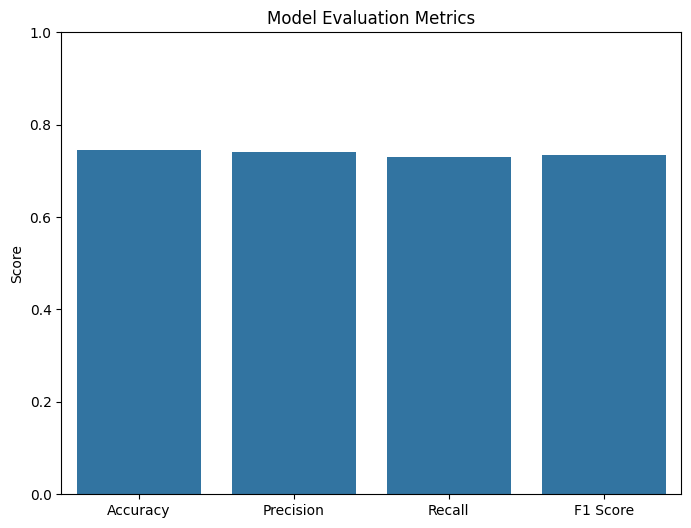

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
knn_model2.evaluate()
knn_model2.plot_metrics()

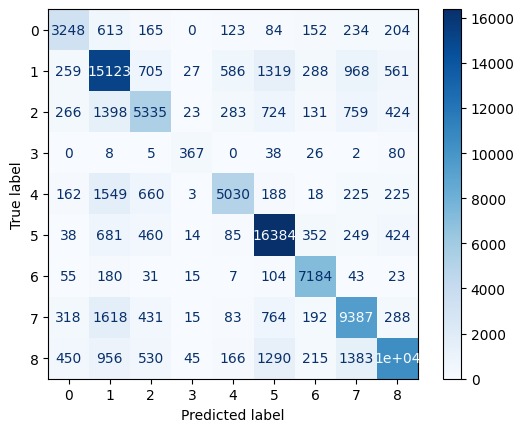

In [ ]:
knn_model.plot_confusion_matrix()

##  Tuning parameter(n_neighbors) for KNN cross-validation

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {'n_neighbors': range(1, 31)}  # Explore values from 1 to 30

# Create a KNN classifier
knn = KNeighborsClassifier()

# Create a GridSearchCV object
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')  # 5-fold cross-validation

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Print the best parameter value and the corresponding score
print("Best n_neighbors:", grid_search.best_params_['n_neighbors'])
print("Best accuracy:", grid_search.best_score_)

# Create a new KNN model with the best parameter
best_knn_model = KNeighborsClassifier(n_neighbors=grid_search.best_params_['n_neighbors'])

# Train the best model on the full training data
best_knn_model.fit(X_train, y_train)

# Evaluate the best model on the testing data
y_pred = best_knn_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on testing data:", accuracy)

KeyboardInterrupt: 

In [ ]:
best_knn_model.plot_metrics()
best_knn_model.plot_confusion_matrix()

NameError: name 'best_knn_model' is not defined

# Gradient Boosting Classifier


In [33]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.model_selection import GridSearchCV
class GradientBoostingModel:
    def __init__(self, X_train, X_test, y_train, y_test, random_state=42):
        """
        Initializes the Gradient Boosting model with training and testing datasets.
        """
        self.X_train, self.X_test = X_train, X_test
        self.y_train, self.y_test = y_train, y_test

        # Initialize the Gradient Boosting Classifier
        self.model = GradientBoostingClassifier(n_estimators=10, learning_rate=0.1, max_depth=3, random_state=random_state)

    def train(self):
        """
        Trains the Gradient Boosting model using the training dataset.
        """
        self.model.fit(self.X_train, self.y_train)

    def predict(self):
        """
        Predicts the labels for the test dataset.
        """
        return self.model.predict(self.X_test)

    def evaluate(self):
        """
        Evaluates the model performance using various metrics.
        """
        y_pred = self.predict()

        # Calculate performance metrics
        self.accuracy = accuracy_score(self.y_test, y_pred)
        self.precision = precision_score(self.y_test, y_pred, average='macro', zero_division=0)
        self.recall = recall_score(self.y_test, y_pred, average='macro', zero_division=0)
        self.f1 = f1_score(self.y_test, y_pred, average='macro', zero_division=0)

        # Compute confusion matrix
        self.conf_matrix = confusion_matrix(self.y_test, y_pred)

        # Print metrics
        print(f"Accuracy: {self.accuracy:.2f}")
        print(f"Precision: {self.precision:.2f}")
        print(f"Recall: {self.recall:.2f}")
        print(f"F1 Score: {self.f1:.2f}")

    def plot_metrics(self):
        """
        Plots accuracy, precision, recall, and F1 score as a bar chart.
        """
        metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
        values = [self.accuracy, self.precision, self.recall, self.f1]

        plt.figure(figsize=(8, 6))
        sns.barplot(x=metrics, y=values)
        plt.title('Model Evaluation Metrics')
        plt.ylabel('Score')
        plt.ylim(0, 1)
        plt.show()

    def plot_confusion_matrix(self):
        """
        Plots the confusion matrix.
        """
        y_pred = self.predict()
        cm = confusion_matrix(self.y_test, y_pred)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap="Blues")
        plt.show()

    def tune_parameters(self, param_grid, cv=5):
        """
        Tunes the hyperparameters of the Gradient Boosting model using Grid Search and Cross-Validation.

        Args:
            param_grid (dict): A dictionary containing the hyperparameters to tune and their possible values.
            cv (int, optional): The number of cross-validation folds. Defaults to 5.
        """
        grid_search = GridSearchCV(self.model, param_grid, cv=cv, scoring='accuracy')
        grid_search.fit(self.X_train, self.y_train)

        # Update the model with the best parameters found
        self.model = grid_search.best_estimator_

        print("Best parameters:", grid_search.best_params_)
        print("Best accuracy:", grid_search.best_score_)


In [34]:
gb_model = GradientBoostingModel(X_train, X_test, y_train, y_test)

In [36]:
gb_model.train()  # Train the model with the best parameters

Accuracy: 0.60
Precision: 0.68
Recall: 0.52
F1 Score: 0.55


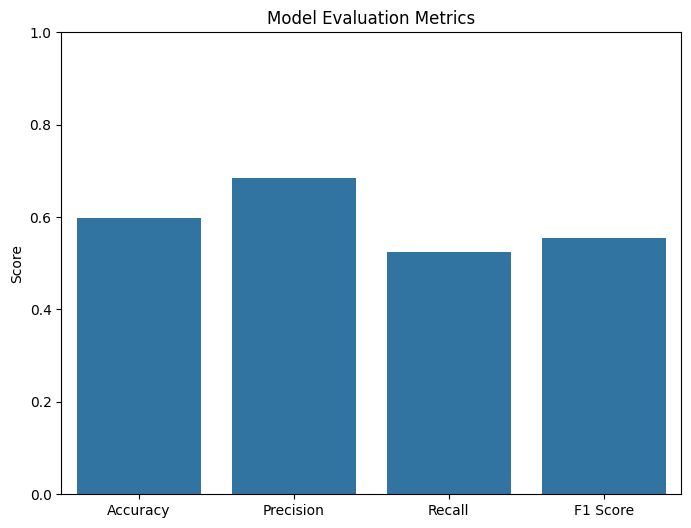

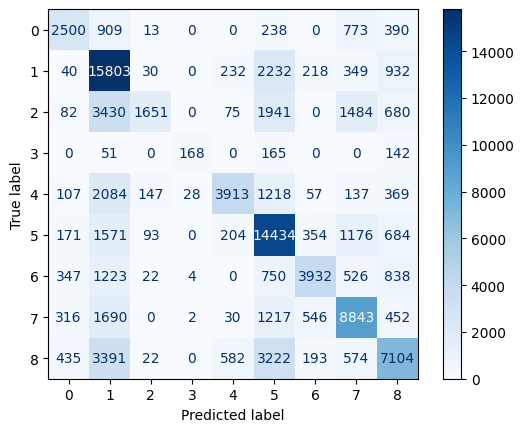

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

gb_model.evaluate()
gb_model.plot_metrics()
gb_model.plot_confusion_matrix()

# Logistic regression

## Data exploration

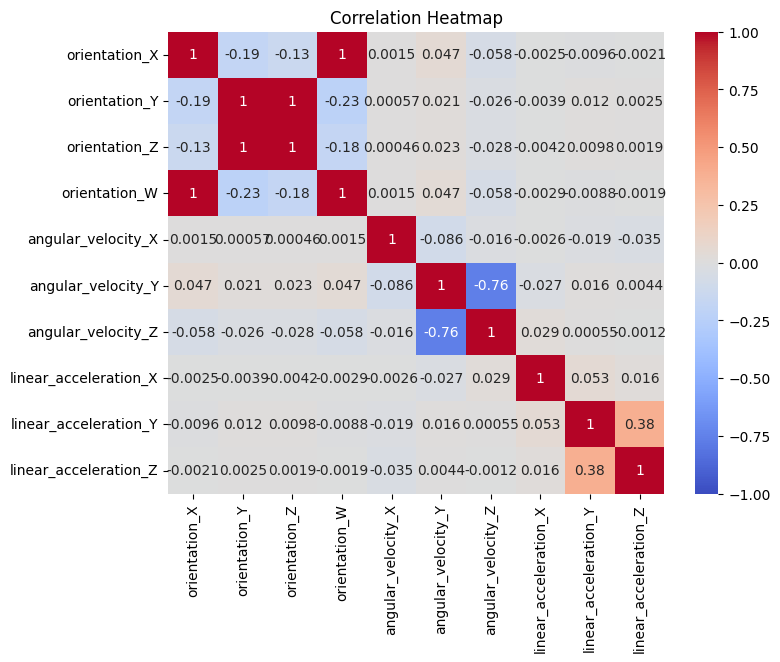

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Create a heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# # Standardize the data (PCA is sensitive to scale)
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(df)



Transformed data with PCA components:
[[-0.72397439 -0.99902427]
 [-0.65359014 -0.55626923]
 [-0.01986818 -1.19068364]
 ...
 [ 1.78143288  2.41345401]
 [ 0.81650617  2.90698213]
 [-0.37351293  1.62287363]]


## Preprocess for logistic regression

surface
concrete                  20.446194
soft_pvc                  19.212598
wood                      15.931759
tiled                     13.490814
fine_concrete              9.527559
hard_tiles_large_space     8.083990
soft_tiles                 7.795276
carpet                     4.960630
hard_tiles                 0.551181
Name: proportion, dtype: float64


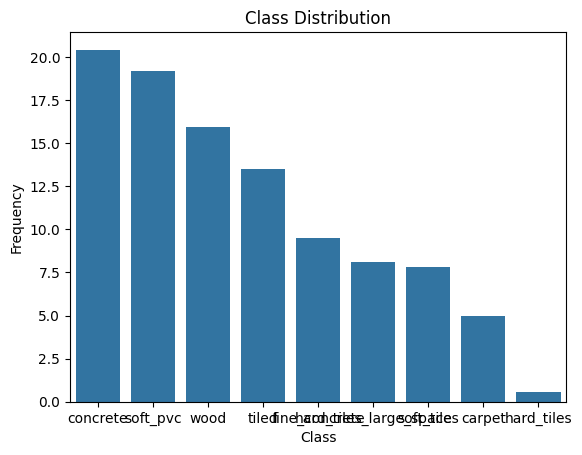

In [ ]:
#check class data balance:
# Count occurrences of each class
class_counts = y.value_counts(normalize=True)*100

print(class_counts)

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.title("Class Distribution")
plt.show()

In [ ]:
X_Scaled_df = pd.DataFrame(X_Scaled, columns=X.columns)
X_withImportantFeatures = X_Scaled_df.iloc[:, [4, 7]]
min_max_scaler = preprocessing.MinMaxScaler()
X_minmax = min_max_scaler.fit_transform(X_withImportantFeatures)

# Apply PCA
pca = PCA(n_components=10)  # Choose the number of components you want
X_pca = pca.fit_transform(X)

print("Transformed data with PCA components:")
print(X_pca)

Transformed data with PCA components:
[[-7.23974386e-01 -9.99024269e-01  1.02993360e-01 ...  2.46324967e-02
  -6.45701453e-03  1.30379695e-03]
 [-6.53590144e-01 -5.56269234e-01 -1.10350485e+00 ...  3.42941821e-02
  -6.55331959e-03  1.29304310e-03]
 [-1.98681797e-02 -1.19068364e+00 -9.05376840e-01 ...  2.50557382e-02
  -6.57832038e-03  1.28419729e-03]
 ...
 [ 1.78143288e+00  2.41345401e+00 -1.00277591e+00 ... -5.01723742e-02
   3.05358082e-02  1.09493961e-03]
 [ 8.16506170e-01  2.90698213e+00 -1.40691694e-01 ... -3.52632874e-02
   3.04990758e-02  1.06447262e-03]
 [-3.73512928e-01  1.62287363e+00  9.48856715e-01 ... -1.21053997e-02
   3.04341685e-02  1.01588390e-03]]


               PC1           PC2           PC3           PC4           PC5  \
PC1   1.000000e+00  2.132349e-15  1.749572e-15  2.479108e-16 -2.794481e-16   
PC2   2.132349e-15  1.000000e+00 -2.542486e-15  4.068992e-16 -6.523060e-16   
PC3   1.749572e-15 -2.542486e-15  1.000000e+00  2.100469e-16 -7.210140e-16   
PC4   2.479108e-16  4.068992e-16  2.100469e-16  1.000000e+00 -2.054390e-15   
PC5  -2.794481e-16 -6.523060e-16 -7.210140e-16 -2.054390e-15  1.000000e+00   
PC6  -2.286148e-16 -2.636957e-16  9.186363e-16  2.744230e-16  5.487199e-16   
PC7   4.615597e-16  3.118414e-16 -1.465852e-15 -2.868979e-15 -4.189778e-15   
PC8  -1.136421e-15  4.212804e-15 -4.499514e-15 -6.554368e-16 -1.065201e-15   
PC9   4.565934e-15  2.803090e-14  2.830059e-14  1.144364e-13  1.417615e-13   
PC10  1.340206e-13  1.510982e-13  1.604126e-13 -1.561793e-13 -1.697931e-13   

               PC6           PC7           PC8           PC9          PC10  
PC1  -2.286148e-16  4.615597e-16 -1.136421e-15  4.565934e-15  1.

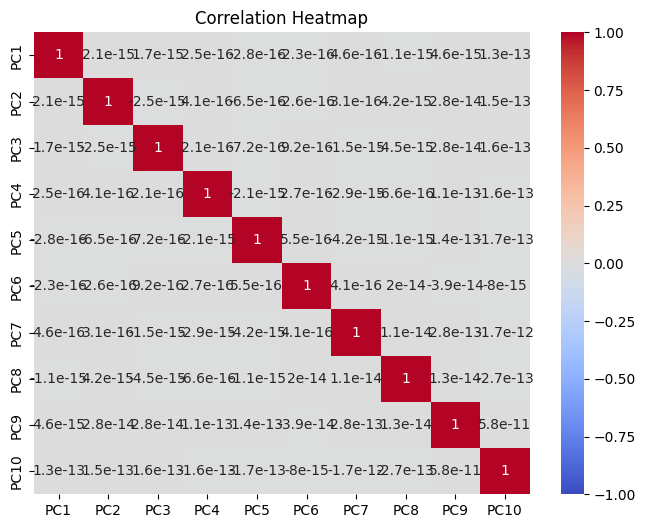

In [ ]:
# Example: Create a heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
print(X_pca_df.corr())
sns.heatmap(X_pca_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_pca, y, test_size=0.2, random_state=42)

## Train

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.multiclass import OneVsOneClassifier


# # Define the parameter grid to search
# param_grid = {
#     'C': [0.001, 0.01, 0.1, 1, 10, 100],
#     'solver': ['saga', 'liblinear'],
#     'penalty': ['l1', 'l2']
# }
# # Create a KNN classifier
# knn = LogisticRegression(max_iter=1000)

# # Create a GridSearchCV object
# grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')  # 5-fold cross-validation

# grid_search.fit(X_train, y_train)
# print(grid_search)

model = OneVsOneClassifier(LogisticRegression(
    C=10.0,
    solver='sag',
    random_state=42,
    penalty="l2",
    max_iter=2000,
    class_weight='balanced'
))

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
import seaborn as sns
class LogisticRegressionModel:
    def __init__(self, X_train, X_test, y_train, y_test, model):

        # Split the data into training and testing sets
        self.X_train, self.X_test, self.y_train, self.y_test = X_train, X_test, y_train, y_test

        # Initialize the Logistic Regression model
        self.model = model

    def train(self):
        """Trains the Logistic Regression model."""
        self.model.fit(self.X_train, self.y_train)

    def predict(self):
        """Makes predictions using the trained model."""
        return self.model.predict(self.X_test)

    def evaluate(self):
        """Evaluates the model performance."""
        y_pred = self.predict()

        # Calculate metrics
        # self.accuracy = accuracy_score(self.y_test, y_pred)
        self.accuracy = accuracy_score(self.y_test, self.predict())
        self.precision = precision_score(self.y_test, y_pred, average='macro', zero_division=0)
        self.recall = recall_score(self.y_test, y_pred, average='macro', zero_division=0)
        self.f1 = f1_score(self.y_test, y_pred, average='macro', zero_division=0)

        # Confusion Matrix
        self.conf_matrix = confusion_matrix(self.y_test, y_pred)

        print(f"Accuracy: {self.accuracy:.2f}")
        print(f"Precision: {self.precision:.2f}")
        print(f"Recall: {self.recall:.2f}")
        print(f"F1 Score: {self.f1:.2f}")

    def plot_metrics(self):
        """Plots accuracy, precision, recall, and F1 score."""
        metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
        values = [self.accuracy, self.precision, self.recall, self.f1]

        plt.figure(figsize=(8, 6))
        sns.barplot(x=metrics, y=values)
        plt.title('Model Evaluation Metrics')
        plt.ylabel('Score')
        plt.ylim(0, 1)
        plt.show()

    def plot_confusion_matrix(self):
        """Plots the confusion matrix."""
        y_pred = self.predict()
        cm = confusion_matrix(self.y_test, y_pred)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap="Blues")
        plt.show()
        # plt.title('Confusion Matrix')
        # plt.xlabel('Predicted')
        # plt.ylabel('True')
        # plt.show()

In [ ]:
logisticRegression = LogisticRegressionModel(X_train_lr, X_test_lr, y_train_lr, y_test_lr, model)
logisticRegression.train()
logisticRegression.evaluate()

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

KeyboardInterrupt: 

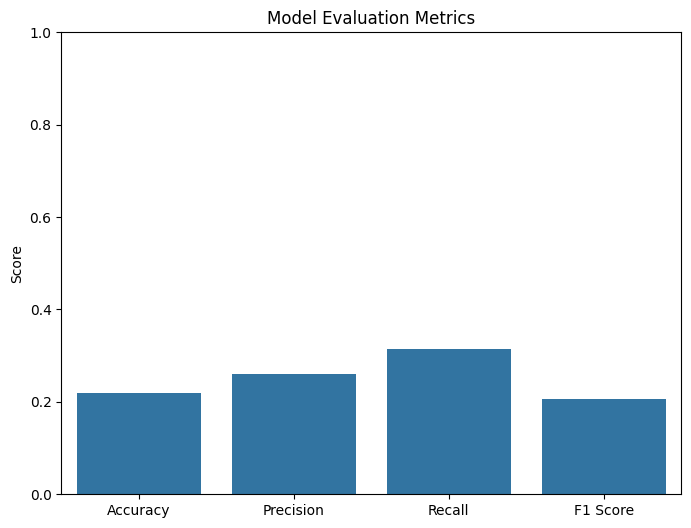

In [ ]:
logisticRegression.plot_metrics()

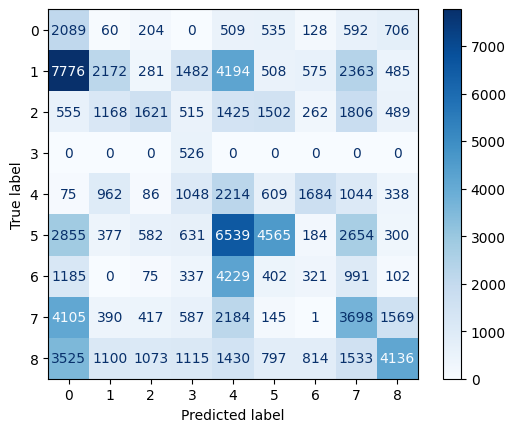

In [ ]:
logisticRegression.plot_confusion_matrix()

# Support Vector Machine (SVM)

## Preprocessing

In [ ]:
# convert labels to onehotencoding:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
# y_oneHotEncoded = encoder.fit_transform(df[['surface']])

# X_Scaled_df = pd.DataFrame(X_Scaled, columns=X.columns)
# X_withImportantFeatures = X_Scaled_df.iloc[:, [4, 7]]
# min_max_scaler = preprocessing.MinMaxScaler()
# X_minmax = min_max_scaler.fit_transform(X_withImportantFeatures)

In [ ]:
X_Scaled

array([[-1.07989683, -1.00167508, -1.10725045, ..., -0.46928895,
        -0.36609528, -0.13647385],
       [-1.07989683, -1.00166096, -1.10743918, ...,  0.11262123,
        -0.64487185, -0.01683956],
       [-1.07989683, -1.00167508, -1.10762791, ..., -0.21039847,
        -0.60477961,  0.2242917 ],
       ...,
       [ 0.94350897, -1.19124743, -0.91347304, ...,  1.37684263,
         0.64284601,  0.42897738],
       [ 0.94368397, -1.19109211, -0.91412415, ...,  1.28927705,
         0.85349381, -0.02762914],
       [ 0.94385898, -1.1909368 , -0.91437894, ...,  0.37134063,
         0.64887386, -0.39823535]])

## split

In [ ]:
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_Scaled, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import json
import os
class SvcModel:
    def __init__(self, X_train, X_test, y_train, y_test, random_state=42):

        # Split the data into training and testing sets
        self.X_train, self.X_test, self.y_train, self.y_test = X_train, X_test, y_train, y_test

        # Initialize the SVC
        self.model = SVC(C=10.0,
                         class_weight='balanced',
                         kernel='linear',
                        #  degree=3,
                         gamma='scale',
                        #  decision_function_shape='ovr',  # One-vs-rest for multiclass
                         random_state=42)

    def train(self):
        """Trains the SVC."""
        self.model.fit(self.X_train, self.y_train)
        return self

    def predict(self):
        """Makes predictions using the trained model."""
        return self.model.predict(self.X_test)

    def evaluate(self):
        """Evaluates the model performance."""
        y_pred = self.predict()

        # Calculate metrics
        self.accuracy = accuracy_score(self.y_test, y_pred)
        self.precision = precision_score(self.y_test, y_pred, average='macro', zero_division=0)
        self.recall = recall_score(self.y_test, y_pred, average='macro', zero_division=0)
        self.f1 = f1_score(self.y_test, y_pred, average='macro', zero_division=0)

        # Confusion Matrix
        self.conf_matrix = confusion_matrix(self.y_test, y_pred)

        print(f"Accuracy: {self.accuracy:.2f}")
        print(f"Precision: {self.precision:.2f}")
        print(f"Recall: {self.recall:.2f}")
        print(f"F1 Score: {self.f1:.2f}")

    def plot_metrics(self):
        """Plots accuracy, precision, recall, and F1 score."""
        metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
        values = [self.accuracy, self.precision, self.recall, self.f1]

        plt.figure(figsize=(8, 6))
        sns.barplot(x=metrics, y=values)
        plt.title('Model Evaluation Metrics')
        plt.ylabel('Score')
        plt.ylim(0, 1)
        plt.show()
        return self

    def plot_confusion_matrix(self):
        """Plots the confusion matrix."""
        y_pred = self.predict()
        cm = confusion_matrix(self.y_test, y_pred)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap="Blues")
        plt.title('Confusion Matrix')
        plt.tight_layout()
        plt.show()
        return self

    def tune_hyperparameters(self, param_grid=None, save_path="/content/drive/MyDrive/ML-data/best_svm_params.json"):
        """Performs grid search to find optimal hyperparameters."""
        if param_grid is None:
            param_grid = {
                'C': [0.01, 0.1, 1, 10, 100, 1000],  # Adding smaller and larger values
                'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],  # Exploring more kernels
                'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 10],  # More control over gamma
                'degree': [2, 3, 4, 5],  # Only relevant for the 'poly' kernel
                'coef0': [0.0, 0.5, 1.0],  # Important for 'poly' and 'sigmoid' kernels
                'class_weight': ['balanced', None]
            }

        grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy')
        grid_search.fit(self.X_train, self.y_train)
        # Save the best parameters
        best_params = grid_search.best_params_
        with open(save_path, "w") as f:
            json.dump(best_params, f)
        self.model = grid_search.best_estimator_
        print(f"Best parameters: {grid_search.best_params_}")
        return self

    def cross_validate(self, cv=5):
        """Performs cross-validation on the training data."""
        from sklearn.model_selection import cross_val_score
        scores = cross_val_score(self.model, self.X_train, self.y_train, cv=cv, scoring='accuracy')
        print(f"Cross-validation accuracy: {scores.mean():.2f} ± {scores.std():.2f}")
        return self

    def save_model(self, filepath="/content/drive/MyDrive/ML-data/svm_model.pkl"):
        """Saves the trained model to a file."""
        import joblib
        joblib.dump(self.model, filepath)
        print(f"Model saved to {filepath}")
        return self

    def load_model(self, filepath="/content/drive/MyDrive/ML-data/svm_model.pkl"):
        """Loads a trained model from a file."""
        import joblib
        if os.path.exists(filepath):
            self.model = joblib.load(filepath)
            print(f"Model loaded from {filepath}")
        else:
            print("No saved model found. Train and save it first.")
        return self

    def plot_feature_importance(self, feature_names=None):
        """Plots feature importances for linear kernel SVM."""
        if self.model.kernel != 'linear':
            print("Feature importance is only available for linear kernel")
            return self

        coef = self.model.coef_
        # For multiclass, average the coefficients
        if coef.shape[0] > 1:
            importances = np.abs(coef).mean(axis=0)
        else:
            importances = np.abs(coef[0])

        if feature_names is None:
            feature_names = [f"Feature {i}" for i in range(len(importances))]

        indices = np.argsort(importances)[::-1]

        plt.figure(figsize=(10, 6))
        plt.bar(range(len(importances)), importances[indices])
        plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
        plt.xlabel("Features")
        plt.ylabel("Importance")
        plt.title("Feature Importance in Linear SVM")
        plt.tight_layout()
        plt.show()
        return self

    def load_best_params(self, param_path="/content/drive/MyDrive/ML-data/best_svm_params.json"):
        """Loads best parameters from a file and sets up the model."""
        if os.path.exists(param_path):
            with open(param_path, "r") as f:
                best_params = json.load(f)
            print(f"Loaded best parameters: {best_params}")
            self.model = SVC(**best_params, random_state=42)
        else:
            print("No saved parameters found. Run tuning first.")
        return self

### Training

In [ ]:
svcModel = SvcModel(X_train_svm, X_test_svm, y_train_svm, y_test_svm)
svcModel.train()  # 📌 Saves the trained model

### Load model and use it

In [ ]:
svcModel = SvcModel(X_train_svm, X_test_svm, y_train_svm, y_test_svm)
svcModel.load_model().evaluate()